# Chapter 17: Structural Breaks

**AFML Ch. 17** -- Detecting regime changes and explosive behavior in financial time series.

Structural break tests are essential for identifying bubbles, crashes, and regime transitions.
This notebook demonstrates several tests from the econometrics literature, all implemented in
`pymlfinance` with both NumPy and Polars interfaces.

**Topics covered:**

- ADF test for stationarity
- SADF (Supremum ADF) for bubble detection
- GSADF for multiple bubble detection
- Brown-Durbin-Evans CUSUM test
- Chu-Stinchcombe-White test
- Polars integration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pymlfinance
import pymlfinance.polars

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
np.random.seed(42)

## Generate Synthetic Data with a Bubble

We construct a synthetic log-price series with four distinct regimes:

1. **Normal regime** (bars 0--100): random walk with small drift
2. **Bubble** (bars 100--150): explosive growth (positive drift added)
3. **Crash** (bars 150--200): sharp decline (negative drift)
4. **Recovery** (bars 200--300): return to normal random walk

This structure lets us verify that bubble detection tests correctly identify the explosive period.

In [2]:
n = 300
# Normal regime + bubble + crash + recovery
normal1 = np.cumsum(np.random.randn(100) * 0.01)
bubble = np.cumsum(np.random.randn(50) * 0.01 + 0.02)  # explosive growth
crash = np.cumsum(np.random.randn(50) * 0.02 - 0.03)   # sharp decline
normal2 = np.cumsum(np.random.randn(100) * 0.01)
log_prices = np.concatenate([normal1, normal1[-1] + bubble,
                              normal1[-1] + bubble[-1] + crash,
                              normal1[-1] + bubble[-1] + crash[-1] + normal2])
log_prices = log_prices + 4.6  # ~100 price level

print(f"Generated {len(log_prices)} log prices with embedded bubble (bars 100-150)")

Generated 300 log prices with embedded bubble (bars 100-150)


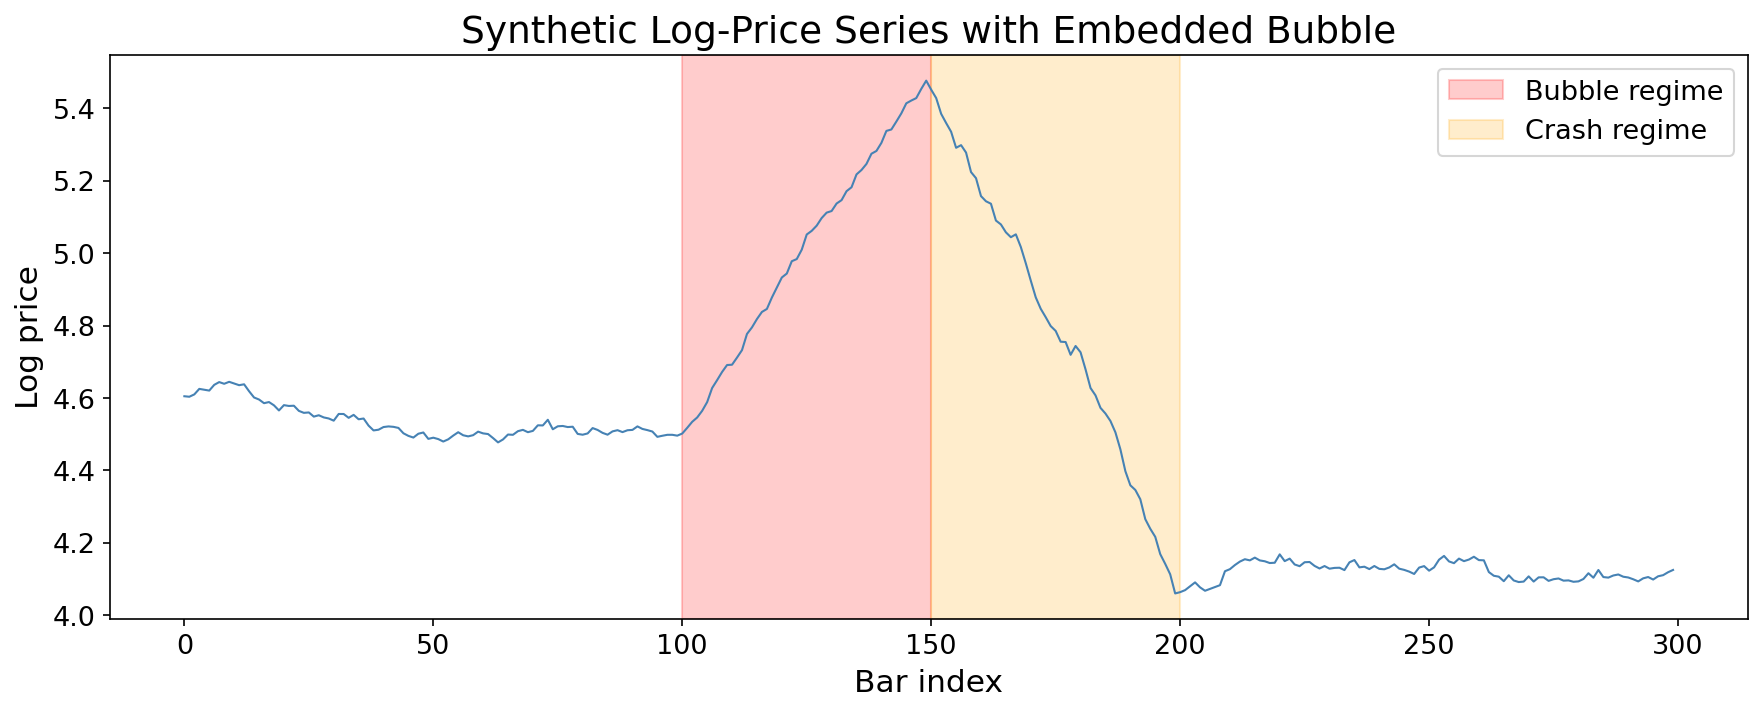

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log_prices, color="steelblue", linewidth=1)
ax.axvspan(100, 150, alpha=0.2, color="red", label="Bubble regime")
ax.axvspan(150, 200, alpha=0.2, color="orange", label="Crash regime")
ax.set_xlabel("Bar index")
ax.set_ylabel("Log price")
ax.set_title("Synthetic Log-Price Series with Embedded Bubble")
ax.legend()
plt.tight_layout()
plt.show()

## ADF Test

The Augmented Dickey-Fuller test checks for the presence of a unit root. A more negative
ADF statistic provides stronger evidence of stationarity. Standard critical values:

| Significance | Critical Value |
|:---:|:---:|
| 1% | -3.43 |
| 5% | -2.86 |
| 10% | -2.57 |

In [4]:
adf_stat, coeffs = pymlfinance.features.adf_test(log_prices, max_lags=1)
print(f"--- ADF Test (full series) ---")
print(f"  ADF statistic: {adf_stat:.4f}")
print(f"  (More negative = more likely stationary)")
print(f"  Critical values: -3.43 (1%), -2.86 (5%), -2.57 (10%)")
if adf_stat < -2.86:
    print(f"  Result: STATIONARY at 5% level")
else:
    print(f"  Result: NON-STATIONARY (unit root present)")

--- ADF Test (full series) ---
  ADF statistic: -0.4406
  (More negative = more likely stationary)
  Critical values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
  Result: NON-STATIONARY (unit root present)


## SADF Test (Supremum ADF)

The SADF test runs recursive ADF regressions with an expanding window starting from
`min_window`. The supremum (maximum) of the ADF statistics is taken as the test statistic.
A positive SADF value is evidence of explosive behavior (bubble).

The SADF series shows the rolling ADF statistic over time, allowing us to pinpoint
*when* explosive behavior begins and ends.

In [5]:
min_window = 30
sadf_series = pymlfinance.features.sadf(log_prices, min_window=min_window, max_lags=1)
sadf_max = pymlfinance.features.sadf_stat(log_prices, min_window=min_window, max_lags=1)
print(f"--- SADF (Supremum ADF) ---")
print(f"  SADF statistic: {sadf_max:.4f}")
print(f"  Series length: {len(sadf_series)}")
print(f"  (Positive SADF = evidence of explosive behavior)")

# Find the bubble region in SADF
if len(sadf_series) > 0:
    peak_idx = np.argmax(sadf_series)
    print(f"  Peak SADF at index {peak_idx + min_window} (value: {sadf_series[peak_idx]:.4f})")
    # Show around the bubble region
    bubble_start = max(0, 100 - min_window)
    bubble_end = min(len(sadf_series), 150 - min_window)
    if bubble_end > bubble_start:
        bubble_sadfs = sadf_series[bubble_start:bubble_end]
        print(f"  Mean SADF in bubble region: {np.mean(bubble_sadfs):.4f}")
        print(f"  Max SADF in bubble region:  {np.max(bubble_sadfs):.4f}")

--- SADF (Supremum ADF) ---
  SADF statistic: 4.7989
  Series length: 271
  (Positive SADF = evidence of explosive behavior)
  Peak SADF at index 146 (value: 4.7989)
  Mean SADF in bubble region: 2.3485
  Max SADF in bubble region:  4.7989


## GSADF Test (Generalized SADF)

GSADF extends SADF by also varying the *start* point of the window, not just the end point.
This gives it greater power to detect multiple bubbles in a single series, and is the
preferred test when the series may contain more than one explosive episode.

In [6]:
gsadf_series = pymlfinance.features.gsadf(log_prices, min_window=min_window, max_lags=1)
gsadf_max = pymlfinance.features.gsadf_stat(log_prices, min_window=min_window, max_lags=1)
print(f"--- GSADF (Generalized SADF) ---")
print(f"  GSADF statistic: {gsadf_max:.4f}")
print(f"  Series length: {len(gsadf_series)}")

--- GSADF (Generalized SADF) ---
  GSADF statistic: 4.8563
  Series length: 36856


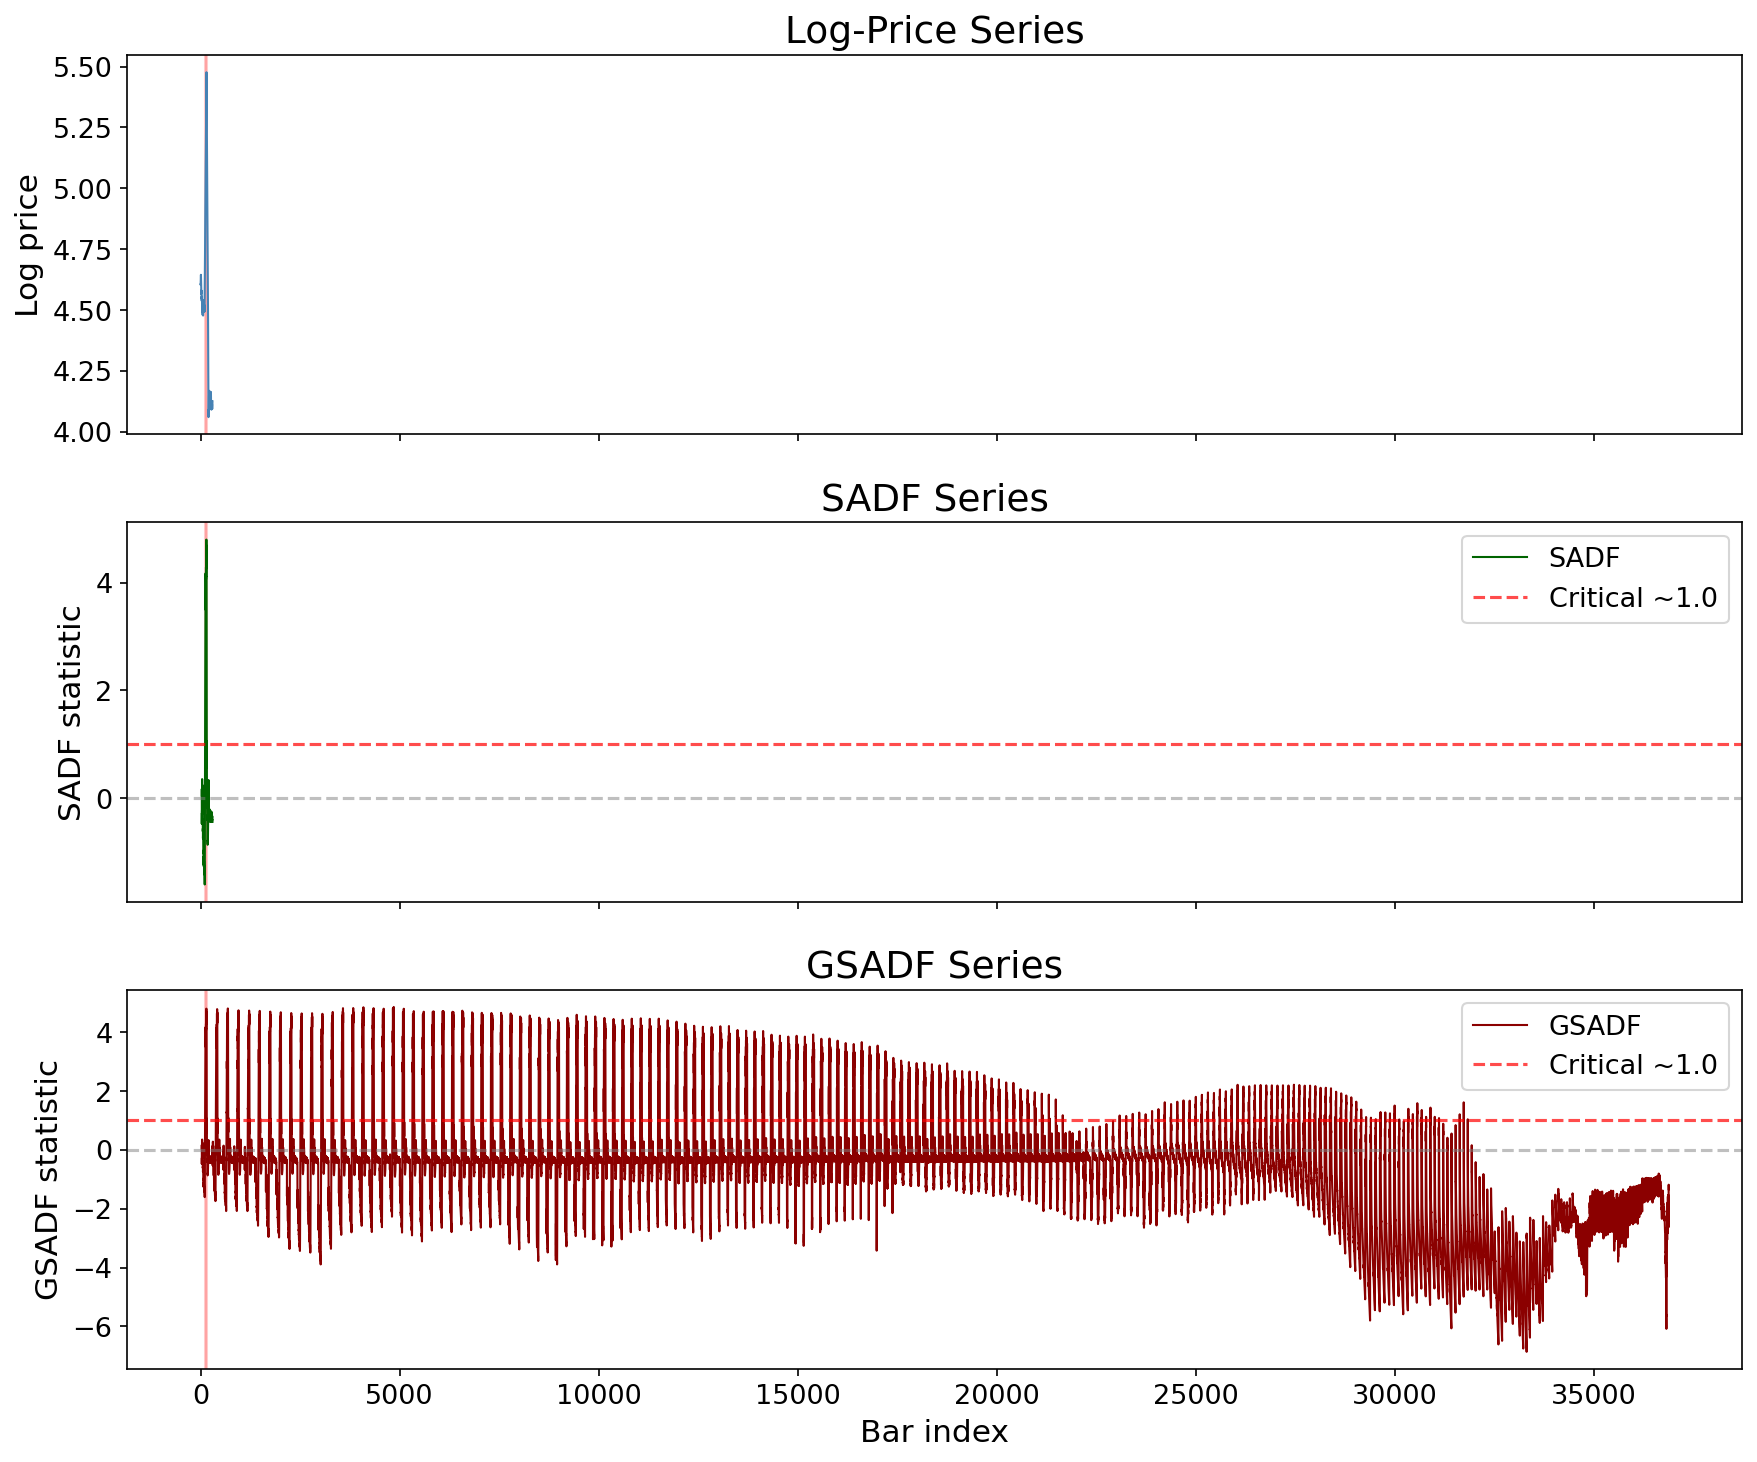

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Price series
axes[0].plot(log_prices, color="steelblue", linewidth=1)
axes[0].axvspan(100, 150, alpha=0.2, color="red")
axes[0].set_ylabel("Log price")
axes[0].set_title("Log-Price Series")

# SADF series
sadf_x = np.arange(min_window, min_window + len(sadf_series))
axes[1].plot(sadf_x, sadf_series, color="darkgreen", linewidth=1, label="SADF")
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="Critical ~1.0")
axes[1].axvspan(100, 150, alpha=0.2, color="red")
axes[1].set_ylabel("SADF statistic")
axes[1].set_title("SADF Series")
axes[1].legend()

# GSADF series
gsadf_x = np.arange(min_window, min_window + len(gsadf_series))
axes[2].plot(gsadf_x, gsadf_series, color="darkred", linewidth=1, label="GSADF")
axes[2].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[2].axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="Critical ~1.0")
axes[2].axvspan(100, 150, alpha=0.2, color="red")
axes[2].set_xlabel("Bar index")
axes[2].set_ylabel("GSADF statistic")
axes[2].set_title("GSADF Series")
axes[2].legend()

plt.tight_layout()
plt.show()

## Brown-Durbin-Evans CUSUM Test

The CUSUM (cumulative sum) test detects parameter instability by tracking the cumulative
sum of recursive residuals. When the CUSUM path crosses the critical boundary lines,
it signals a structural break. We use first differences of log prices as the residuals.

In [8]:
residuals = np.diff(log_prices)
cusum, critical = pymlfinance.features.brown_durbin_evans(residuals)
print(f"--- Brown-Durbin-Evans CUSUM ---")
print(f"  Critical value (5%): {critical:.4f}")
print(f"  Max |CUSUM|: {np.max(np.abs(cusum)):.4f}")
exceedances = np.sum(np.abs(cusum) > critical)
print(f"  Bars exceeding critical: {exceedances}")

--- Brown-Durbin-Evans CUSUM ---
  Critical value (5%): 1.3580
  Max |CUSUM|: 3.5202
  Bars exceeding critical: 61


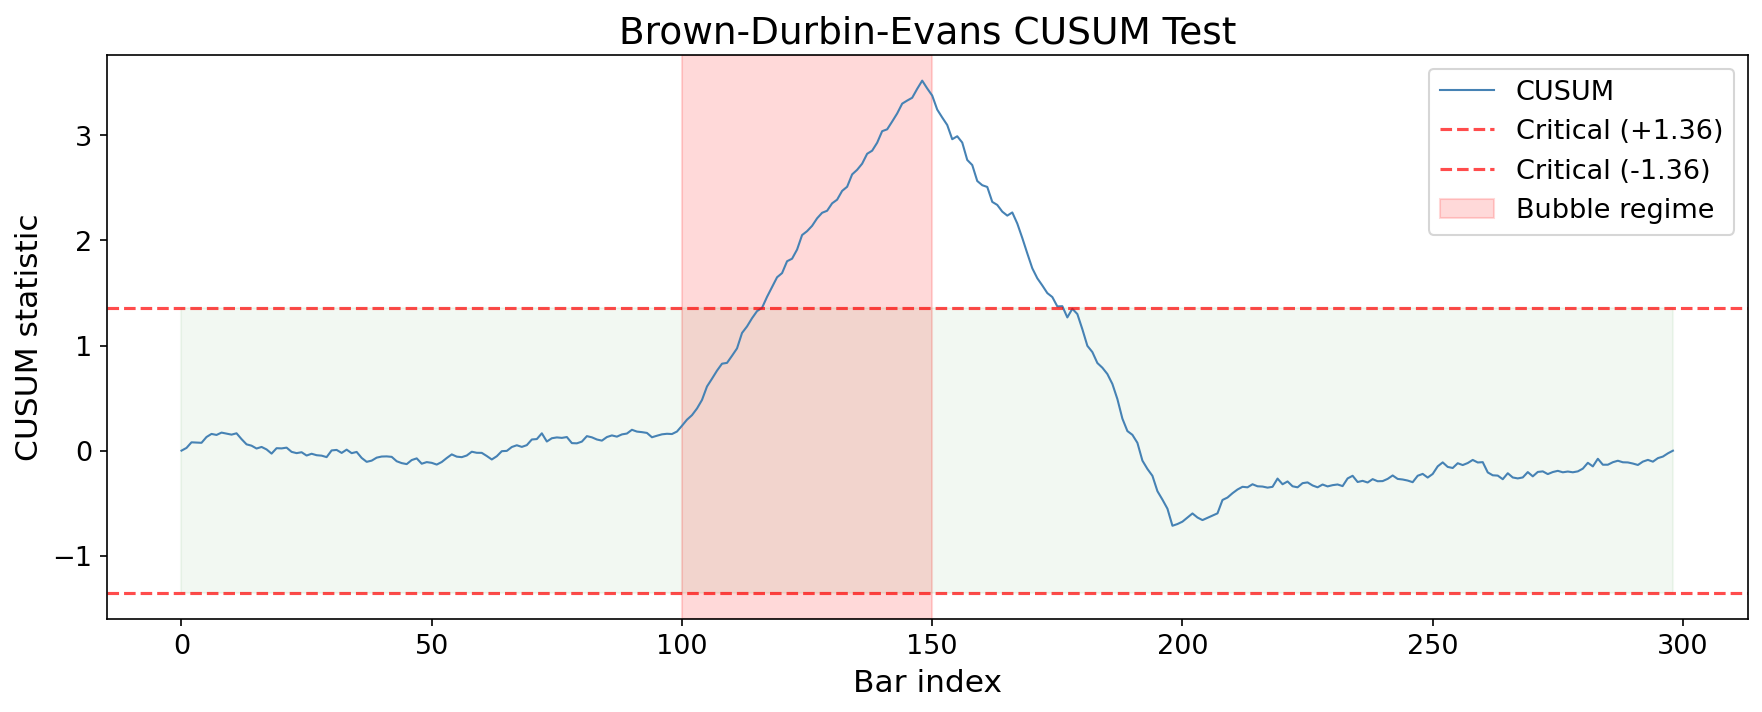

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
cusum_x = np.arange(len(cusum))
ax.plot(cusum_x, cusum, color="steelblue", linewidth=1, label="CUSUM")
ax.axhline(y=critical, color="red", linestyle="--", alpha=0.7, label=f"Critical (+{critical:.2f})")
ax.axhline(y=-critical, color="red", linestyle="--", alpha=0.7, label=f"Critical (-{critical:.2f})")
ax.axvspan(100, 150, alpha=0.15, color="red", label="Bubble regime")
ax.fill_between(cusum_x, -critical, critical, alpha=0.05, color="green")
ax.set_xlabel("Bar index")
ax.set_ylabel("CUSUM statistic")
ax.set_title("Brown-Durbin-Evans CUSUM Test")
ax.legend()
plt.tight_layout()
plt.show()

## Chu-Stinchcombe-White Test

The CSW test is a one-sided CUSUM variant designed to detect explosive behavior
in asset prices. It tests the null of a random walk against the alternative of
explosive growth.

In [10]:
csw = pymlfinance.features.chu_stinchcombe_white(log_prices, critical_value=1.96)
print(f"--- Chu-Stinchcombe-White ---")
print(f"  CSW series length: {len(csw)}")
print(f"  Max CSW statistic: {np.max(csw):.4f}")
print(f"  Bars exceeding 1.96: {np.sum(csw > 1.96)}")

--- Chu-Stinchcombe-White ---
  CSW series length: 299
  Max CSW statistic: 1.9474
  Bars exceeding 1.96: 0


## Polars API

All structural break tests are also available through the Polars expression API
via the `.ml` namespace, making it easy to integrate into Polars data pipelines.

In [11]:
df = pl.DataFrame({"log_price": log_prices})
adf_pl = df.select(pl.col("log_price").ml.adf_test(max_lags=1)).item()
print(f"  Polars ADF: {adf_pl:.4f}")

sadf_df = df.with_columns(
    pl.col("log_price").ml.sadf(min_window=min_window, max_lags=1).alias("sadf"),
)
print(f"  Polars SADF series length: {sadf_df['sadf'].drop_nulls().len()}")

  Polars ADF: -0.4406
  Polars SADF series length: 300


## Exercises

1. **Vary the bubble intensity** -- Change the drift term in the bubble regime (currently `0.02`) and observe how the SADF statistic responds. At what drift level does SADF fail to detect the bubble?

2. **Add multiple bubbles** -- Insert a second bubble period later in the series. Compare SADF vs GSADF detection power. Which test identifies both episodes?

3. **Try different `min_window` sizes** -- Use values like 15, 30, 60, and 100. Observe the tradeoff between sensitivity and false positives in the SADF/GSADF series.